## ENTRENAMIENTO DE MODELOS EN BASE A NUESTRO DATASET PREPROCESADO ANTERIORMENTE
#### Dentro de este jupyter se presenta todo el proceso de entrenamiento de un nuevo modelo en base a los datos que recopilamos y preprocesamos en el notebook anterior. Este notebook presenta todo el proceso de entrenamiento, evaluación y ajuste fino para la clasificación de los paradigmas dentro de una señal EEG
##### Este notebook es una muestra simple de cómo poder usar la librería `Backend_DL`para un pipeline completo de formación de modelos de predicción de paradigmas EEG, con ayuda de ***EEGNET*** y *TensorFLOW* 

##### Los objetivos principales de esta librería son:

- Creación de un objeto para la preselección de los datos 
- Preselección de las clases para entrenar
- Selección de los canales a utilizar
- Creación de npz a formato compatible con entrenamiento de Keras 
- Separación de clases y undersampleo y balance de las mismas 
- Split de los datos de entrenamiento con estratificación en sujetos, sesiones o triales compatibles con el formato [MOABB](https://moabb.neurotechx.com/docs/index.html)
- Normalización de los datos para keras
- Entrenamiento general del modelo con definición de hiperparámetros 
- Aplicación de ajuste fino 
- Evaluación y métricas de los modelos

### 1) Establecer área de trabajo (Pueden ignorar esta primera celda y sólo importar la librería)

In [1]:
import os
import sys
import numpy as np
import pandas as pd

project_path = r'C:\Users\Josjuan\Desktop\Tesis\Movement_clasify' 
print(f"Ruta de trabajo actual: {project_path}")



os.chdir(project_path) #change directory B)



#Rutas donde tenemos demás recursos
scripts_path = os.path.join(project_path, 'scripts')

#Asegurarnos de que todos existan
if os.path.exists(scripts_path): #Donde están nuestras librerían
    if scripts_path not in sys.path:
        sys.path.append(scripts_path)
        print(f"✅ Path agregado: {scripts_path}")
else: print(f"No encontrse encontró la carpeta en {scripts_path}")

#Importamos nuestras librerías internas
import backend_DL_v2 as dl

Ruta de trabajo actual: C:\Users\Josjuan\Desktop\Tesis\Movement_clasify
✅ Path agregado: C:\Users\Josjuan\Desktop\Tesis\Movement_clasify\scripts


### Definición de variables

In [2]:
## Variables del modelo general: 

val_size = 0.20 #Tamaño para el set de validación
undersample_rest = False #Recortar la clase mayoritaria rest para balance de clases
use_class_weight = True #Usar la función de sklearn para balancear las clases (sobretodo rest)
mode = "subject" #Donde estratificar los sets de train y val (Por sujetos)
make_test_gen = False #Crear un subset de validación final (No, porque usamos sujetos externos)
dinamic_lr_gen = False #Usar learning rate dinámico (no sirvió de mucho)
patience_level_gen = 'medium' 
epochs_gen = 60
Lr_gen = 1e-4 
dropout_rate = 0.25 
batch_gen = 32
apply_lsf = False #Aplicar transformada espacial 
apply_ea = True #Aplicar alineación euclideana 

## Variables del modelo de afinamiento 

val_size_ft = 0.25 #Subset de validación
normalize = True #False: Normalizar con datos propios del sujeto, True: normalizar con los datos del general
epochs_ft = 200
lr_ft = 1e-4
batch_ft = 32
unfreeze_layers = 8 #Capas finales a descongelar (Eran 16 al final)
monitor = 'val_loss'
patience_level_ft = 'high'






### 2) Creación de objeto y selección de canales, al crear del objeto se pueden especificar: 
- La selección de canales
- La posibilidad de undersamplear las clases mayoritarias por balance 
- Posibilidad de fusionar o no las clases imaginarias con las motoras

##### Load: Carga el path y carga a sus vez sus atributos de cada dato 
##### pipeline: fusiona clases, construye atrivutos principales y agrega las respectivas clases
Deja todo listo en los sets para entrenar




In [11]:
path_train = "Recursos/Grupo_B/train_2/eeg_dataset_27_ch_0.00015rate.npz" #Path con todos los sujetos para entrenar
path_fine = "Recursos/Grupo_B/fine_2/eeg_dataset_27_ch_0.00015rate.npz" #Todos los 5 sujetos los cuales se va a realizar ssft
path_test = "Recursos/Grupo_B/fine_2/eeg_dataset_27_ch_0.00015rate.npz" #Los mismos sujetos, pero con el dataset para testear
#La razón por la cual este último es diferente es porque el set de validación podría tener otros bordes y/o configuración

In [12]:
"""            
            0: FULL           
            1: SOLO MOTOR (5 clases)
            2: SOLO IMAGINADO 5 CLASES
            3: 9 CLASES SIN FUSIÓN
            4: REST-IZQ-DER fusionado
            5: REST-MANOS-PIES fusionado
            6: REST-IZQ-DER SOLO MOTOR
            7: REST-MANOS-PIES SOLO MOTOR
            8: TODAS CLASES BINARIO (REST vs MOVIMIENTO)
            9: REST vs MOVIMIENTO SOLO MOTOR
            10: MANOS VS PIES, fusionado
            11: MANOS VS PIES, solo motor
            12: DERECHA vs IZQUIERDA, fusionado 
            13: DERECHA vs IZQUIERDA, solo motor
            14: IZQ-DER-MANO-PIES FUSIONADAS
            15: IZQ-DER-MANO-PIES SOLO MOTOR
            16: REST-IZQ-DER IMAGINADO
            17: REST-MANOS-PIES IMAGINAGO 
            18: REST VS MOVIMIENTO IMAGINARIO
            19: IZQ VS DER IMAGINAGO
            20: REST-RIGHT-FEET IMAGINADO MOABB
"""


#Probamos nuestro nuevo objeto

train = dl.Selection(pick=4)
fine = dl.Selection(pick=16)
test = dl.Selection(pick=16)




train.load(path_train)
#train.pick_ch(["C3..", "C4..", "Cz.."])
train.pipeline()

fine.load(path_fine)
#fine.pick_ch(["C3..", "C4..", "Cz.."])
fine.pipeline()

test.load(path_test)
#test.pick_ch(["C3..", "C4..", "Cz.."])
test.pipeline()
channels = len(train.X[0])



✔️ Dataset cargado desde: Recursos/Grupo_B/train_2/eeg_dataset_27_ch_0.00015rate.npz
✔️ Dataset cargado desde: Recursos/Grupo_B/fine_2/eeg_dataset_27_ch_0.00015rate.npz
✔️ Dataset cargado desde: Recursos/Grupo_B/fine_2/eeg_dataset_27_ch_0.00015rate.npz


### 2.5) Opcionalmente, se puede usar el atributo "resume_data" para examinar los datos antes del entrenamiento

In [13]:
print("Datos del train:")
train.resume_data()

print("Datos del dataset de finetunnning:")
fine.resume_data()

#print("Datos del dataset del test:")
#test.resume_data()

Datos del train:
X shape: (51453, 27, 320)
y shape: (51453,)
sub shape: (51453,)
trial shape: (51453,)
run shape: (51453,)
Número de clases: 3
Número de sujetos: 95

Clases:
   codigo nombre
0       0   rest
1       1  right
2       2   left

Conteo por clase:
0    25722
1    12789
2    12942
Name: count, dtype: int64
Datos del dataset de finetunnning:
X shape: (1347, 27, 320)
y shape: (1347,)
sub shape: (1347,)
trial shape: (1347,)
run shape: (1347,)
Número de clases: 3
Número de sujetos: 5

Clases:
   codigo   nombre
0       0     rest
1       1  right_i
2       2   left_i

Conteo por clase:
0    675
1    336
2    336
Name: count, dtype: int64


### 3) Con la función "runfolds" se agarran los sdujetos de afinamiento y test, crea diferemntes folds para probar el promedio de los datos 


In [14]:
data_fine_folds, data_test_folds, fold_table = dl.runfolds(
    fine_obj=fine,
    test_obj=test,
    debug = False
)

fold_table





,fold,subject,test_run,fine_runs,test_runs,n_fine,n_test,fine_class_counts,test_class_counts,fine_modes,test_modes
0,0,4,4,"[8, 12]",[4],180,90,"{0: 90, 1: 45, 2: 45}","{0: 45, 1: 21, 2: 24}",['LR_I'],['LR_I']
1,1,4,8,"[4, 12]",[8],180,90,"{0: 90, 1: 42, 2: 48}","{0: 45, 1: 24, 2: 21}",['LR_I'],['LR_I']
2,2,4,12,"[4, 8]",[12],180,90,"{0: 90, 1: 45, 2: 45}","{0: 45, 1: 21, 2: 24}",['LR_I'],['LR_I']
3,3,16,4,"[8, 12]",[4],180,90,"{0: 90, 1: 45, 2: 45}","{0: 45, 1: 24, 2: 21}",['LR_I'],['LR_I']
4,4,16,8,"[4, 12]",[8],180,90,"{0: 90, 1: 48, 2: 42}","{0: 45, 1: 21, 2: 24}",['LR_I'],['LR_I']
5,5,16,12,"[4, 8]",[12],180,90,"{0: 90, 1: 45, 2: 45}","{0: 45, 1: 24, 2: 21}",['LR_I'],['LR_I']
6,6,38,4,"[8, 12]",[4],180,90,"{0: 90, 1: 45, 2: 45}","{0: 45, 1: 21, 2: 24}",['LR_I'],['LR_I']
7,7,38,8,"[4, 12]",[8],180,90,"{0: 90, 1: 45, 2: 45}","{0: 45, 1: 21, 2: 24}",['LR_I'],['LR_I']
8,8,38,12,"[4, 8]",[12],180,90,"{0: 90, 1: 42, 2: 48}","{0: 45, 1: 24, 2: 21}",['LR_I'],['LR_I']
9,9,86,4,"[8, 12]",[4],180,87,"{0: 90, 1: 48, 2: 42}","{0: 45, 1: 21, 2: 21}",['LR_I'],['LR_I']


### 4) Entrenamiento del modelo general con "eeg_train", se establecen las épocas, el modo de estratificación, así como el tamaño de la separación de los datos de entrenamiento y validación

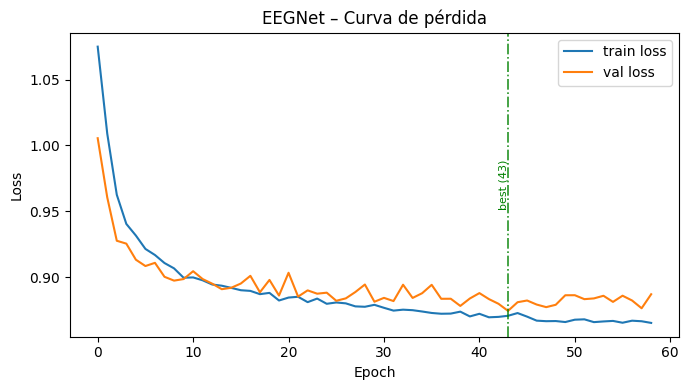

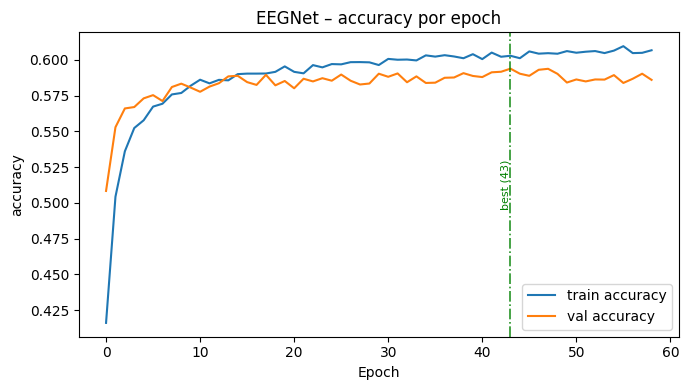

In [16]:


modelo, history, mean, std, keras_split, sorted_test, info = dl.eeg_train(
    train, val_size=val_size, undersample_rest=undersample_rest, use_class_weight=use_class_weight,
    mode=mode, make_test=make_test_gen, test_run=data_test_folds, dynamic_lr = dinamic_lr_gen ,
    epochs=epochs_gen, patience_level=patience_level_gen,
    Lr= Lr_gen,  dropout_rate=dropout_rate, batch = batch_gen, apply_lsf=apply_lsf, apply_ea= apply_ea,
    debug=False
)
dl.plot_history(history, lr_schedule=info["Lr_grid"], best_epoch = info["best_epoch"])


##### 4.5) Examinar modelo obtenido con la función "evaluate_moabb", te da el promedio de cada fold por sujeto, promedio general o resultados generales

In [17]:


df_sub_raw, df_runs_raw, rows_raw = dl.evaluate_moabb(
    modelo,
    test_subsets=data_test_folds,
    mean=mean,
    std=std,
    label_map=train.label_map,
    test_result="subject",
    apply_lsf=apply_lsf,
    apply_ea=apply_ea
)

path_csv = f"Recursos/models/Grupo_B_test/pick16_ea"

if not os.path.exists(path_csv):
    os.makedirs(path_csv)


df_sub_raw.to_csv(f"{path_csv}/EEG_subject.csv")
df_sub_raw

,subject,run,fined,accuracy,macro_f1,balanced_accuracy,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,balanced_accuracy_mean,balanced_accuracy_std
0,86,all,all folds,0.782 ± 0.100,0.752 ± 0.119,0.751 ± 0.116,0.782,0.100,0.752,0.119,0.751,0.116
1,4,all,all folds,0.656 ± 0.040,0.602 ± 0.071,0.621 ± 0.088,0.656,0.040,0.602,0.071,0.621,0.088
2,16,all,all folds,0.585 ± 0.122,0.544 ± 0.138,0.552 ± 0.133,0.585,0.122,0.544,0.138,0.552,0.133
3,105,all,all folds,0.567 ± 0.033,0.528 ± 0.036,0.527 ± 0.043,0.567,0.033,0.528,0.036,0.527,0.043
4,38,all,all folds,0.474 ± 0.013,0.369 ± 0.052,0.389 ± 0.036,0.474,0.013,0.369,0.052,0.389,0.036


In [18]:
#Guardamos el modelo y sus parámetros de normalización

channels = len(train.X[0])

path = f"Recursos/models/Grupo_B_test/pick16_ea"

if not os.path.exists(path):
    os.makedirs(path)

dl.save_model(
    model=modelo,
    mean=mean,
    std=std,
    label_map=test.label_map,
    path=path,
    

    name=f"EEG_net_pick16_ea"
)

Modelo guardado    : Recursos/models/Grupo_B_test/pick16_ea\EEG_net_pick16_ea.keras
Parámetros guardados: Recursos/models/Grupo_B_test/pick16_ea\EEG_net_pick16_ea.npz
Clases del modelo  : {0: 'rest', 1: 'right_i', 2: 'left_i'}
EA incluida        : No


#### 5) Afinamiento, transfer learning, la función "eeg_fine" se encarga de hacer el TL con el modelo general, emn este caso, se agrega un coiclo for para que lpo haga con cada uno de los folds

In [6]:
modelo, mean, std = dl.load_model(model_path=f"Recursos/models/Grupo_B_v2/pick16_ea/EEGNet_pick16_ea.keras", 
                                  params_path=f"Recursos/models/Grupo_B_v2/pick16_ea/EEGNet_pick16_ea.npz"
)

In [14]:
fine = dl.Selection(pick=21)
test = dl.Selection(pick=21)
fine.load(path_fine); fine.pipeline()
test.load(path_test); test.pipeline()

data_fine_list, data_test_list, fold_table = dl.build_list(fine, test)

✔️ Dataset cargado desde: Recursos/GRUPO_HGD/fine/eeg_hgd_27_ch_0.00015rate.npz
✔️ Dataset cargado desde: Recursos/GRUPO_HGD/test/eeg_hgd_27_ch_0.00015rate.npz

BUILD_LIST: PAREJAS FINE/TEST CONSTRUIDAS
Sujetos: 14
    idx  subject  n_fine  n_test
0     0        1     720     357
1     1        2    1824     360
2     2        3    1980     360
3     3        4    2016     360
4     4        5    1620     360
5     5        6    1980     360
6     6        7    1926     354
7     7        8    1473     360
8     8        9    1980     360
9     9       10    1974     360
10   10       11    1980     360
11   11       12    1977     360
12   12       13    1800     360
13   13       14    1980     360



Fold 1/15 | subject=4 | test_run=90
[EA] Calculando R^{-1/2} sobre dataset_fine.X crudo...
[EA] Eigenvalores de R: min=-8.690e-19, max=2.049e-10
[EA] Traza de R antes de alinear: 6.761e-10
[EA] Advertencia: 1 eigenvalor(es) < umbral=2.049e-13, se aplicará regularización.
[EA] Error off-diagonal post-alineación (debe ser ≈ 0): 0.0428
[EA] Alineación aplicada. Traza R antes: 0.000 | Ideal (=n_canales): 27
[EA] Número de condición de R: 235817440.0
Modo de split: trial
n_groups: 60
n_temp: 6
Split por grupo:
  Train: 162 muestras, grupos: [151 152 153 154 156 157 158 159 160 161 162 164 165 166 167 168 169 170
 171 172 173 174 175 176 177 178 179 270 271 272 273 274 275 277 278 279
 280 281 282 283 284 286 287 288 289 290 291 292 293 295 296 297 298 299]
  Val:   18 muestras, grupos: [150 155 163 276 285 294]
  Test:  0 muestras, grupos: []
Modo split: trial
X_train: (162, 27, 320)
X_val: (18, 27, 320)
X_test: (0, 27, 320)
Tamaño del train: (162, 27, 320) Tamaño del val: (18, 27, 320) Ta

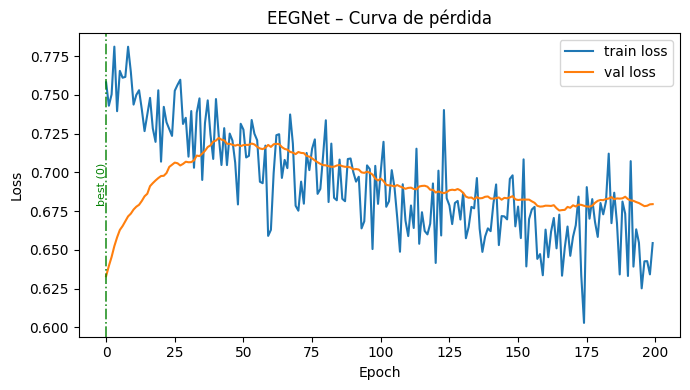

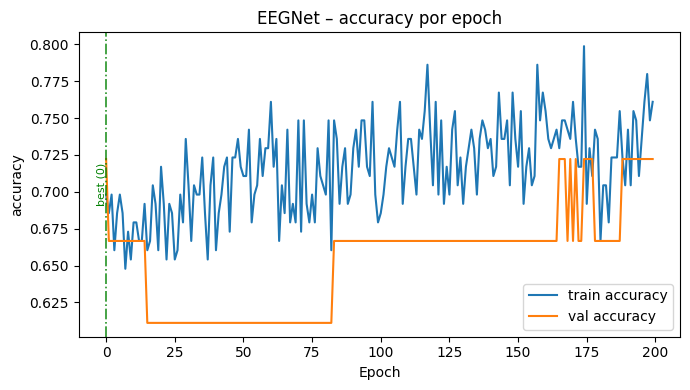


 EVALUACIÓN Mejor fold - test run 8

[Métricas globales]
Accuracy                  : 0.8444
Balanced accuracy         : 0.8111
Macro precision           : 0.8107
Macro recall              : 0.8111
Macro F1                  : 0.8094
Weighted F1               : 0.8444
Cohen's kappa             : 0.7516
Matthews corrcoef         : 0.7527
Log loss                  : 0.5096
ROC-AUC macro             : 0.9582
Chance level              : 0.3333
Accuracy over chance norm : 0.7667

[Clases]
  0: rest
  1: right_i
  2: left_i

[Reporte de clasificación]
              precision    recall  f1-score   support

        rest       0.95      0.93      0.94        45
     right_i       0.74      0.83      0.78        24
      left_i       0.74      0.67      0.70        21

    accuracy                           0.84        90
   macro avg       0.81      0.81      0.81        90
weighted avg       0.85      0.84      0.84        90


[Interpretación rápida]
- Accuracy: rendimiento global.
- Balanced 

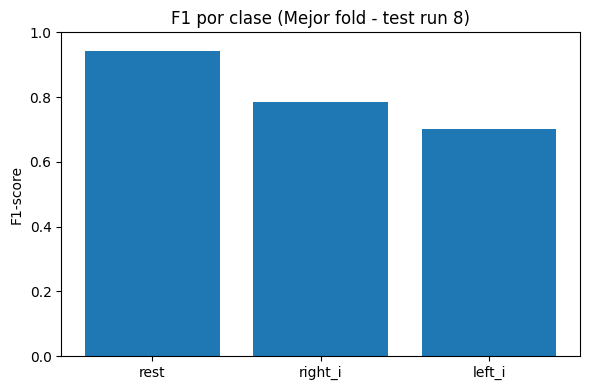

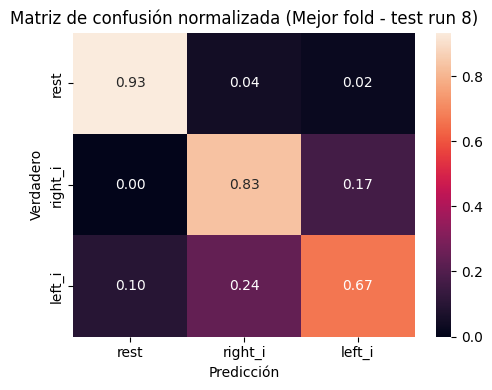

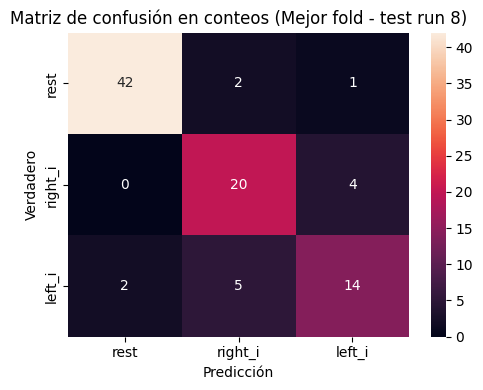

,subject,run,fined,accuracy,macro_f1,balanced_accuracy,accuracy_mean,macro_f1_mean,balanced_accuracy_mean
0,86,all,all folds,0.740 ± 0.101,0.718 ± 0.096,0.728 ± 0.088,0.740,0.718,0.728
1,4,all,all folds,0.693 ± 0.017,0.655 ± 0.017,0.667 ± 0.029,0.693,0.655,0.667
2,105,all,all folds,0.600 ± 0.019,0.566 ± 0.039,0.580 ± 0.063,0.600,0.566,0.580
3,16,all,all folds,0.537 ± 0.042,0.504 ± 0.058,0.520 ± 0.070,0.537,0.504,0.520
4,38,all,all folds,0.367 ± 0.029,0.346 ± 0.039,0.373 ± 0.062,0.367,0.346,0.373


In [22]:
rows = []

models_ft = []
histories_ft = []
splits_ft = []
infos_ft = []
metrics_ft = []
means_ft = []
stds_ft = []
ea_matrices = []


for i in range(len(data_fine_folds)):

    subject_i = fold_table.loc[i, "subject"]
    test_run_i = fold_table.loc[i, "n_test"]

    print("\n" + "=" * 70)
    print(f"Fold {i+1}/{len(data_fine_folds)} | subject={subject_i} | test_run={test_run_i}")
    print("=" * 70)

    modelo_ft, histor_ft, mean_ft, std_ft, keras_split_ft, info_ft, ea_matrix = dl.eeg_fine(modelo, data_fine_folds[i], mean = None, std = None, val_size=0.1,
                                                                            make_test=make_test_gen, test_run=data_test_folds[i], undersample_rest = undersample_rest, normalize = normalize,
                                                                            debug=True, epochs=epochs_ft, lr=lr_ft, batch_size=batch_ft, unfreeze_last_n=8, monitor = monitor,
                                                                            use_class_weight = use_class_weight, patience_level='off',
                                                                            apply_lsf=apply_lsf, apply_ea = apply_ea)
    
    metrics = dl.evaluate(
        modelo_ft, keras_split_ft, label_map=test.label_map,
        title=f"Fine-tuning  N° {i}", plot=False, verbose=False
    )

    row = {
        "fold": i,
        "subject": subject_i,
        "test_run": int(np.unique(data_test_folds[i].run)[0]),
        "fine_runs": str(list(np.unique(data_fine_folds[i].run))),
        "accuracy": metrics["accuracy"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "macro_f1": metrics["macro_f1"]
    }

    for name in metrics["class_names"]:
        clean = str(name).replace(" ", "_")
        row[f"f1_{clean}"] = metrics.get(f"f1_{clean}")
        row[f"recall_{clean}"] = metrics.get(f"recall_{clean}")
        row[f"precision_{clean}"] = metrics.get(f"precision_{clean}")

    rows.append(row)

    models_ft.append(modelo_ft)
    means_ft.append(mean_ft)
    stds_ft.append(std_ft)
    histories_ft.append(histor_ft)
    splits_ft.append(keras_split_ft)
    infos_ft.append(info_ft)
    metrics_ft.append(metrics)
    ea_matrices.append(ea_matrix)

df_runfold = pd.DataFrame(rows)

df_runfold = df_runfold.sort_values(
    by=["macro_f1", "balanced_accuracy", "accuracy"],
    ascending=False
)

best_fold = int(df_runfold.iloc[0]["fold"])

dl.plot_history(histories_ft[best_fold], best_epoch=infos_ft[best_fold].get("best_epoch"))
dl.evaluate(models_ft[best_fold], splits_ft[best_fold], test.label_map, title=f"Mejor fold - test run {df_runfold.iloc[0]['test_run']}",)

df_ft_sub = dl.summarize_finetuning_by_subject(df_runfold)
df_ft_sub



#### 6) Guardar todos los modelos y csv

In [ ]:
path = f"Recursos/models/fined/v4/{pick}_mode_finned_model/{channels}_ch"

if not os.path.exists(path):
    os.makedirs(path)

df_ft_sub.to_csv(f"{path}/runfold_moderun_sfl_ea.csv", index=False)

: 

In [ ]:

path_f = f"Recursos/models/fined/v4/{pick}_mode_finned_model/{channels}_ch"
print(f"Guardando modelo en: {path_f}")

if not os.path.exists(path_f):
    os.makedirs(path_f)

dl.save_model(
    model=models_ft[best_fold],
    mean=means_ft[best_fold],
    std=stds_ft[best_fold],
    label_map=test.label_map,
    path=path_f,
    split = splits_ft[best_fold],
    info = infos_ft[best_fold],
    ea_matrix=ea_matrices[best_fold],
    name=f"EEGNet_bestmodel_ft"
    )



Guardando modelo en: Recursos/models/fined/v4/8_mode_finned_model/7_ch
Modelo guardado: Recursos/models/fined/v4/8_mode_finned_model/7_ch\EEGNet_bestmodel_ft.keras
Parámetros guardados: Recursos/models/fined/v4/8_mode_finned_model/7_ch\EEGNet_bestmodel_ft.npz
Clases del modelo: {0: np.str_('rest'), 1: np.str_('no_rest')}
